In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [ ]:

ROOT_DIR = Path(r"/Users/sonalbhatia/Desktop/Docs/CMU/Lessons/MLIP/Project/Final/shawshank_prediction_team-17")

telemetry_path = ROOT_DIR / "dataset" / "telemetry_recs_dec.txt"
ratings_path = ROOT_DIR / "dataset" / "ratings_dec.log"

telemetry_cols = [
    "timestamp",
    "session_type",  
    "user_id",
    "latency",
    "model_version",
    "recs"
]

telemetry = pd.read_csv(
    telemetry_path,
    header=None,
    names=telemetry_cols,
    dtype={"user_id": "Int64"}
)

ratings = pd.read_csv(
    ratings_path,
    header=None,
    names=["timestamp","user_id","movie_raw","rating"],
    dtype={"user_id": "Int64"}
)

print("Telemetry shape:", telemetry.shape)
print("Ratings shape:", ratings.shape)


Telemetry shape: (355, 6)
Ratings shape: (413, 4)


In [ ]:

telemetry["recs"] = telemetry["recs"].astype(str).str.strip()
telemetry["rec_list"] = telemetry["recs"].str.split("|")
ratings["movie"] = ratings["movie_raw"].astype(str).str.replace("+", " ", regex=False)
rec_exp = telemetry.explode("rec_list").reset_index(drop=True)
rec_exp["movie"] = rec_exp["rec_list"].astype(str).str.replace("+", " ", regex=False)

print(rec_exp.head())


                   timestamp session_type  user_id  latency model_version  \
0  2025-12-01T07:38:19+00:00         cold   492639    2.684            v2   
1  2025-12-01T07:38:19+00:00         cold   492639    2.684            v2   
2  2025-12-01T07:38:19+00:00         cold   492639    2.684            v2   
3  2025-12-01T07:38:19+00:00         cold   492639    2.684            v2   
4  2025-12-01T07:38:19+00:00         cold   492639    2.684            v2   

                                                recs  \
0  alien+1979|raiders+of+the+lost+ark+1981|spirit...   
1  alien+1979|raiders+of+the+lost+ark+1981|spirit...   
2  alien+1979|raiders+of+the+lost+ark+1981|spirit...   
3  alien+1979|raiders+of+the+lost+ark+1981|spirit...   
4  alien+1979|raiders+of+the+lost+ark+1981|spirit...   

                       rec_list                         movie  
0                    alien+1979                    alien 1979  
1  raiders+of+the+lost+ark+1981  raiders of the lost ark 1981  
2       

In [ ]:
cold = rec_exp[rec_exp.session_type == "cold"]
warm = rec_exp[rec_exp.session_type == "warm"]
print("Cold rec rows:", len(cold))
print("Warm rec rows:", len(warm))


Cold rec rows: 3530
Warm rec rows: 20


In [6]:
if len(warm) == 0:
    print("No warm users detected. Creating fallback groups (high vs low activity).")

    user_activity = rec_exp.groupby("user_id").size().sort_values(ascending=False)

    # Top 20% users = high activity (proxy for warm)
    threshold = int(0.2 * len(user_activity))
    high_users = user_activity.head(threshold).index
    low_users = user_activity.tail(threshold).index

    warm = rec_exp[rec_exp.user_id.isin(high_users)]
    cold = rec_exp[rec_exp.user_id.isin(low_users)]

    print("High-activity (warm-proxy):", len(warm))
    print("Low-activity (cold-proxy):", len(cold))


In [ ]:
ratings["hit"] = 1 

merged_cold = cold.merge(
    ratings[["user_id","movie","hit"]],
    on=["user_id","movie"],
    how="left"
)

merged_warm = warm.merge(
    ratings[["user_id","movie","hit"]],
    on=["user_id","movie"],
    how="left"
)

cold_hit_rate = merged_cold["hit"].fillna(0).mean()
warm_hit_rate = merged_warm["hit"].fillna(0).mean()

cold_hit_rate, warm_hit_rate


(0.0005665722379603399, 0.0)

/var/folders/w3/862g6lyn1lq06k96_t0kbq2c0000gn/T/ipykernel_35867/2168063185.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


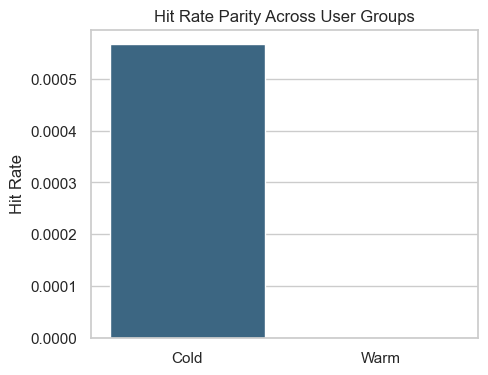

In [8]:
plt.figure(figsize=(5,4))
sns.barplot(
    x=["Cold", "Warm"],
    y=[cold_hit_rate, warm_hit_rate],
    palette="viridis"
)
plt.title("Hit Rate Parity Across User Groups")
plt.ylabel("Hit Rate")
plt.show()


In [ ]:
cold_exposure = cold["movie"].value_counts(normalize=True)
warm_exposure = warm["movie"].value_counts(normalize=True)

exposure_df = pd.DataFrame({
    "cold": cold_exposure,
    "warm": warm_exposure
}).fillna(0)

exposure_df.head(10)


,cold,warm
movie,,
alien 1979,0.049575,0.00
big hero 6 2014,0.052125,0.00
blade runner 1982,0.000000,0.05
coraline 2009,0.049575,0.00
dial m for murder 1954,0.000000,0.05
guardians of the galaxy 2014,0.048159,0.00
howls moving castle 2004,0.048159,0.05
inception 2010,0.054391,0.05
interstellar 2014,0.053258,0.00


In [10]:
def kl_divergence(p, q):
    p = p + 1e-10
    q = q + 1e-10
    return np.sum(p * np.log(p / q))

kl = kl_divergence(
    exposure_df["cold"].values,
    exposure_df["warm"].values
)

print("Exposure KL Divergence (Cold vs Warm):", kl)


Exposure KL Divergence (Cold vs Warm): 10.04552442365155


<Figure size 1000x500 with 0 Axes>

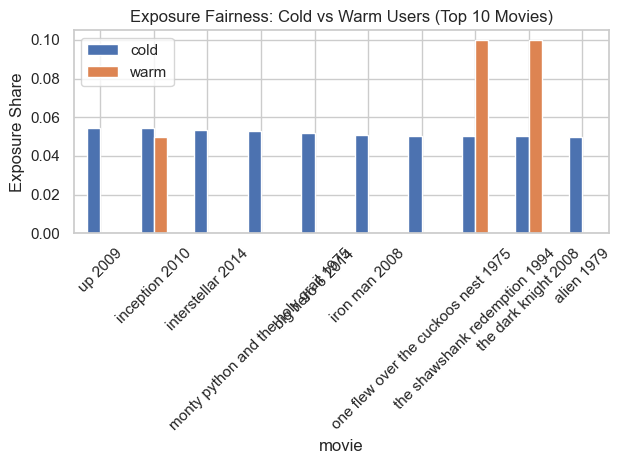

In [11]:
top_movies = exposure_df.sort_values("cold", ascending=False).head(10)

plt.figure(figsize=(10,5))
top_movies.plot(kind="bar")
plt.title("Exposure Fairness: Cold vs Warm Users (Top 10 Movies)")
plt.ylabel("Exposure Share")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
